# WATERSHED ALGORITHM

### Advanced algorithm that allows us to segment images into foreground and background.

### Metaphorically, the watershed algorithm transformation treats the image it operates upon like a topographic map, with the brightness of each point representing its height, and finds the lines that run along the tops of the ridges.

### Grayscale image viewed as topographic surface where
1. High intensity denotes peaks.
2. Low intensity denotes valleys.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def display(img, cmap='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

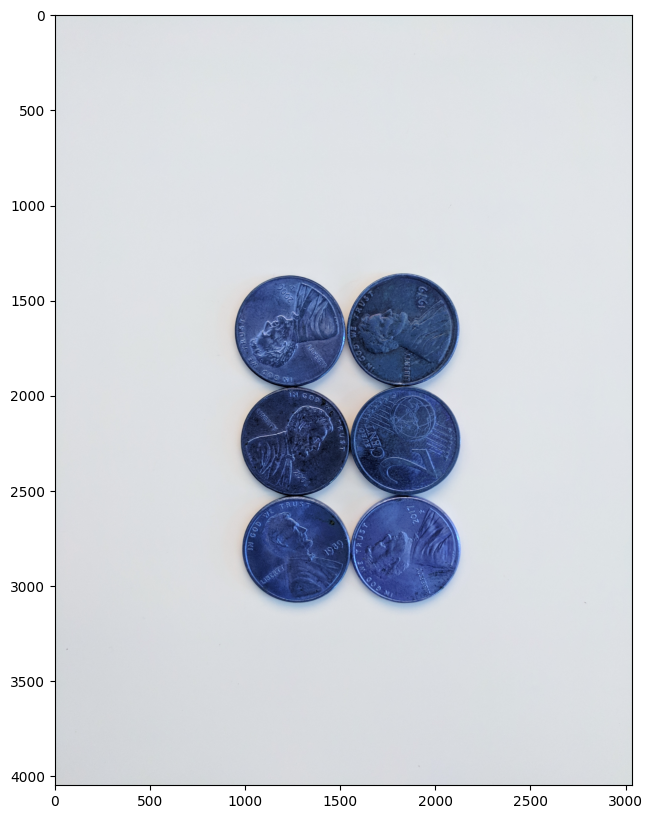

In [4]:
sep_coins = cv2.imread('../DATA/pennies.jpg')
display(sep_coins)

In [5]:
# Steps to Segment each object,
# 1. Median Blur
# 2. Grayscale
# 3. Binary Threshold
# 4. Find Contours

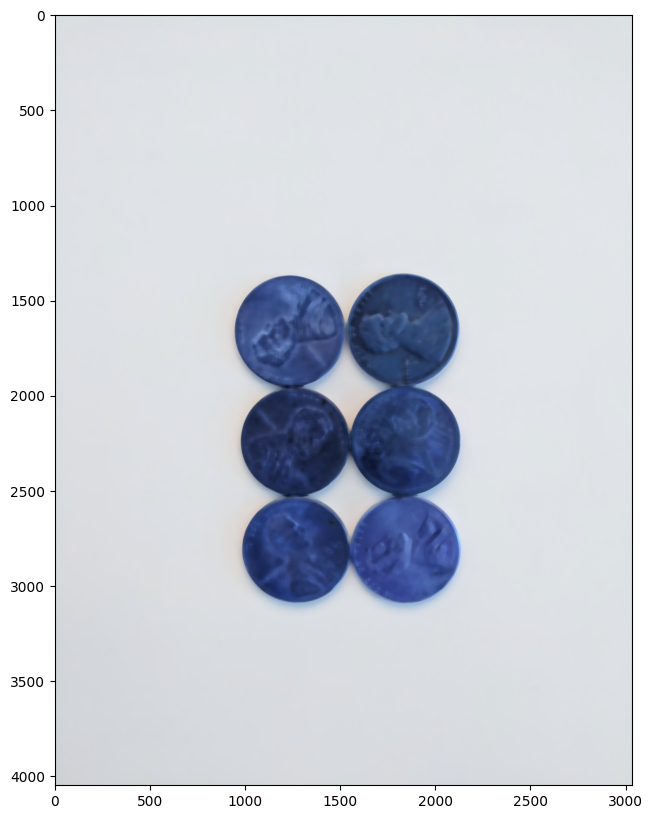

In [6]:
# Finding the Median Blur
sep_blur = cv2.medianBlur(sep_coins, 25)
display(sep_blur)

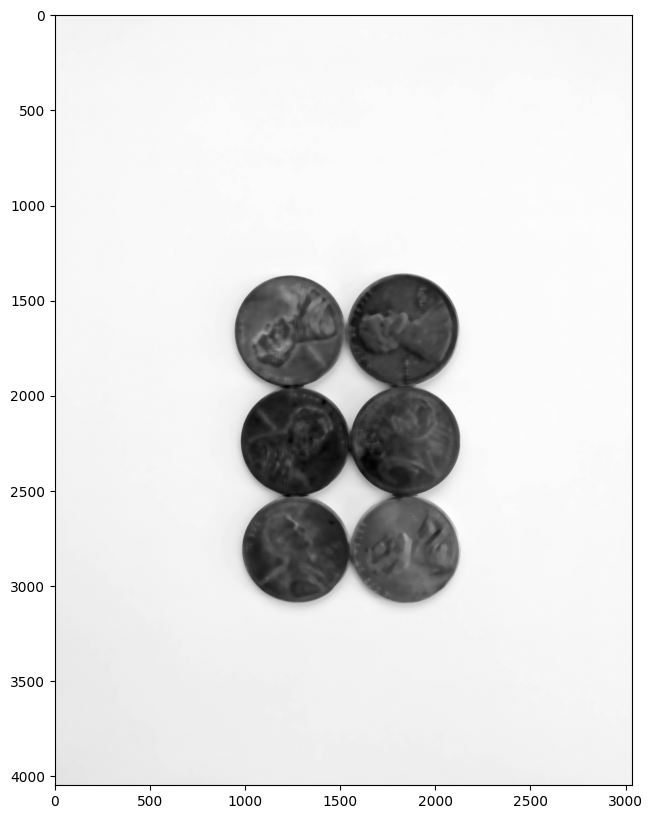

In [7]:
# Finding the Grayscale
gray_sep_coins = cv2.cvtColor(sep_blur, cv2.COLOR_BGR2GRAY)
display(gray_sep_coins)

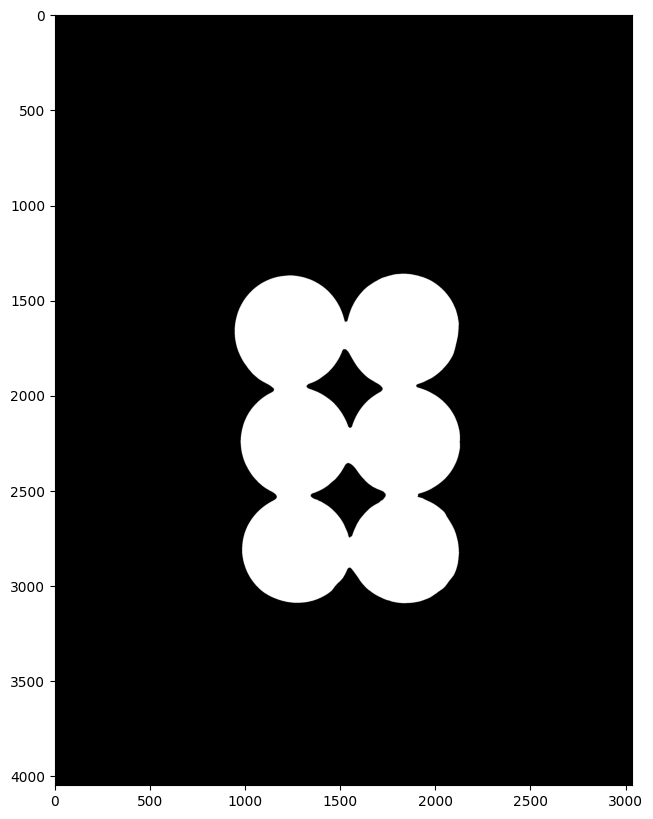

In [8]:
# Finding the Binary Threshold
res, sep_thresh = cv2.threshold(gray_sep_coins, 160, 255, cv2.THRESH_BINARY_INV)
display(sep_thresh)

In [9]:
contours, hierarchy = cv2.findContours(sep_thresh.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

In [10]:
for i in range(len(contours)):
    if hierarchy[0][i][3] == -1:
        cv2.drawContours(sep_coins, contours, i, (255, 0, 0), 10)

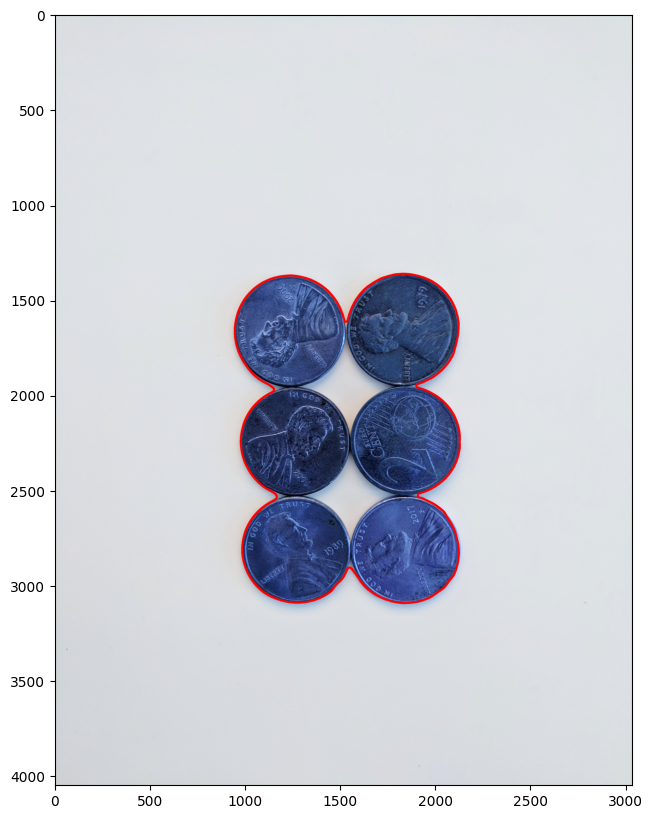

In [11]:
display(sep_coins)

In [12]:
# This was the best naive approach to segment these image, but could not segment it finding internal contours.

### WATERSHED STEPS

In [13]:
img = cv2.imread('../DATA/pennies.jpg')

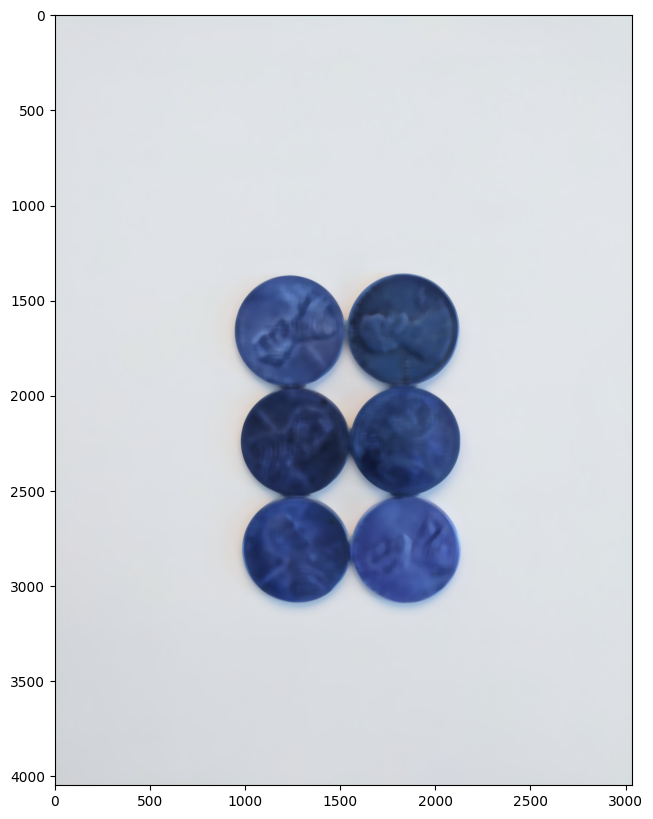

In [14]:
# Blurring
img = cv2.medianBlur(img, 35)
display(img)

In [15]:
# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

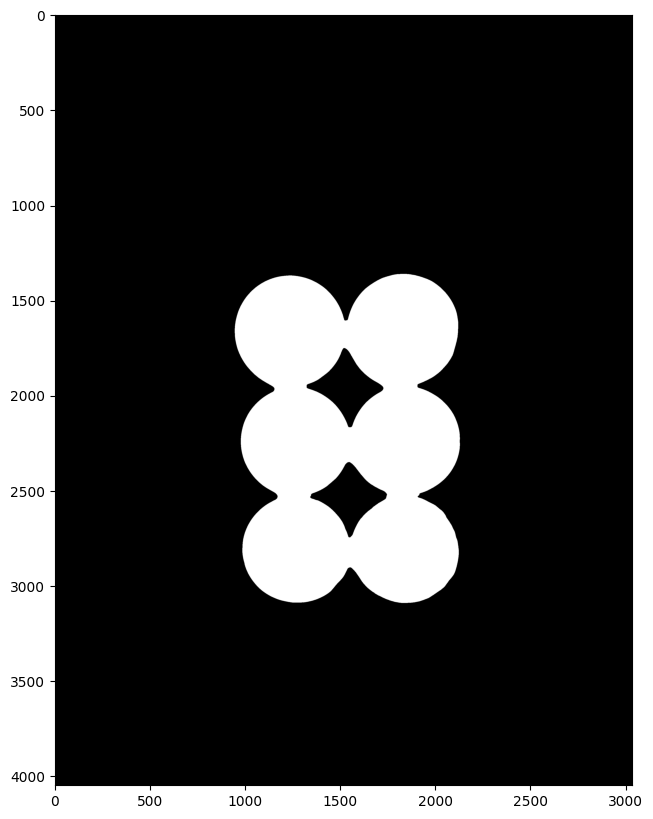

In [16]:
# Applying the OTSU thresholding + Binary inv. Thresholding
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
display(thresh)

In [17]:
# Noise Removal (Optinal)
kernel = np.ones((3,3), np.uint8)
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [18]:
# Removing the noise of threshold image and tried erosion to find contours

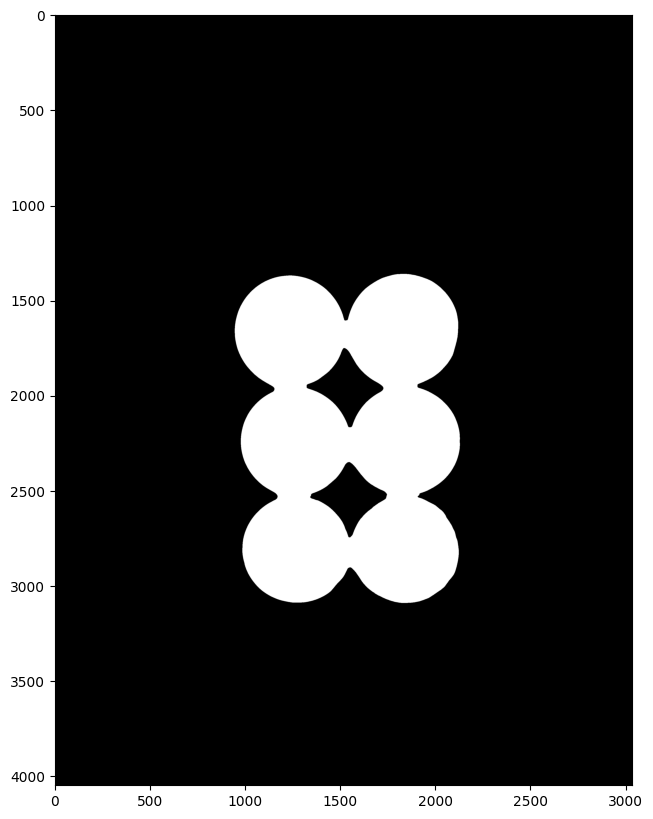

In [19]:
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
display(opening)

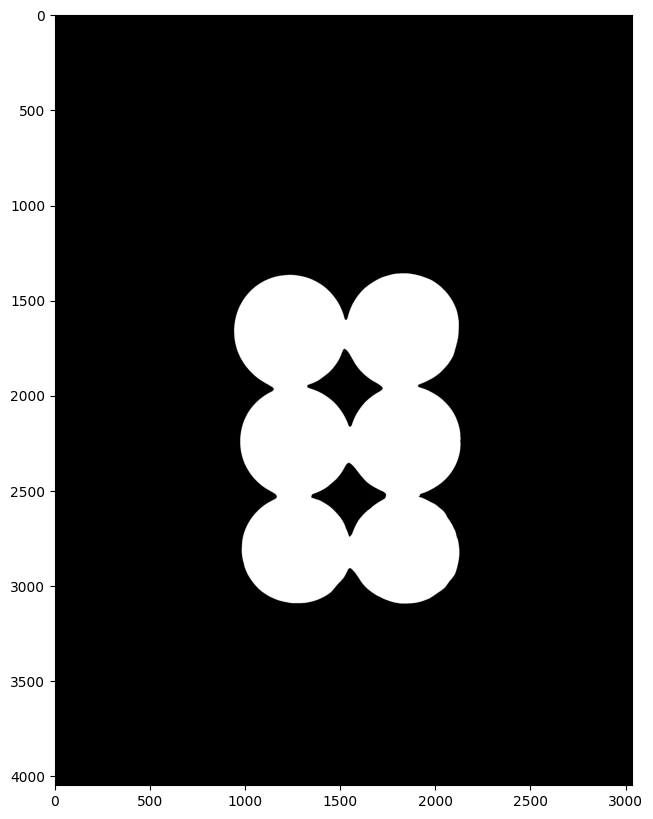

In [20]:
# Taking the background out
sure_bg = cv2.dilate(opening, kernel, iterations=3)
display(sure_bg)

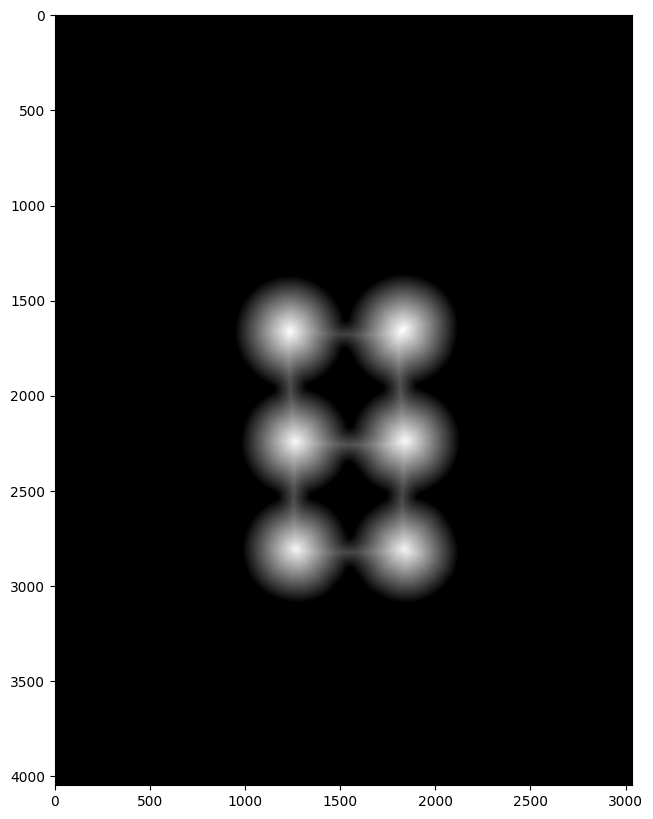

In [21]:
# Distance Transformation -> On Binary Image (converts as Brighter at the core and fades as moves away from core.)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
display(dist_transform)

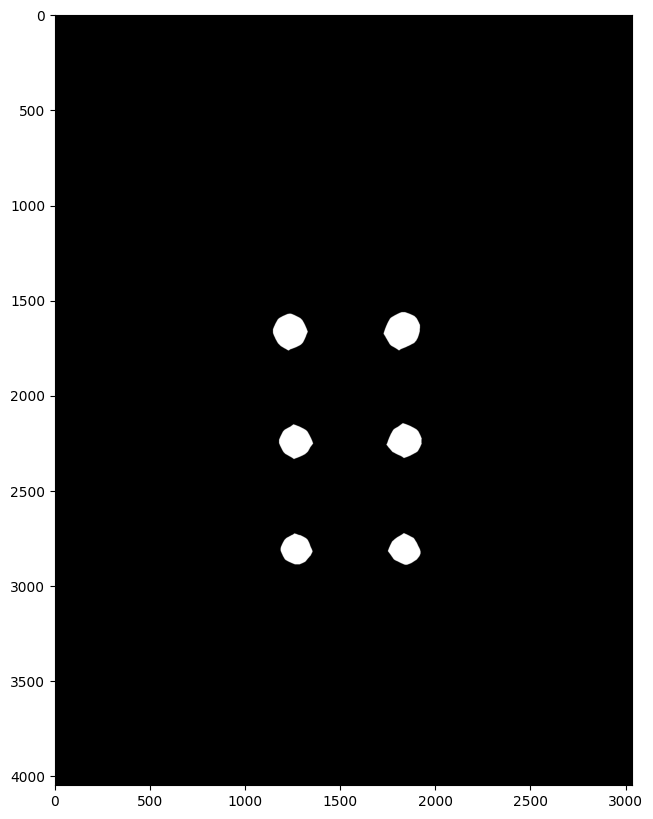

In [22]:
# Takong the foreground out from distance transformed image.
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
display(sure_fg)

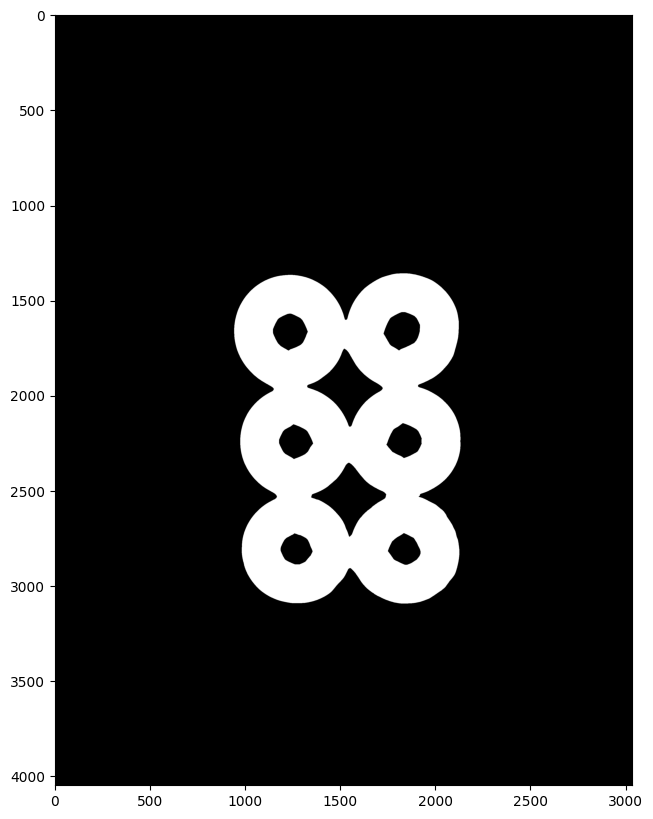

In [23]:
# Subtracting the foreground in background
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
display(unknown)

In [24]:
ret, markers = cv2.connectedComponents(sure_fg)

In [25]:
markers = markers + 1

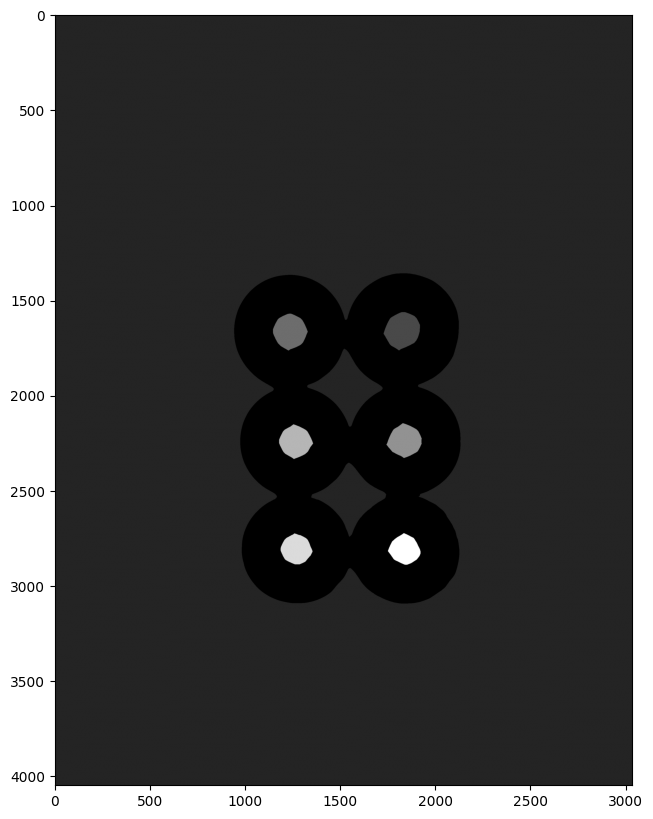

In [26]:
markers[unknown == 255] = 0
display(markers)

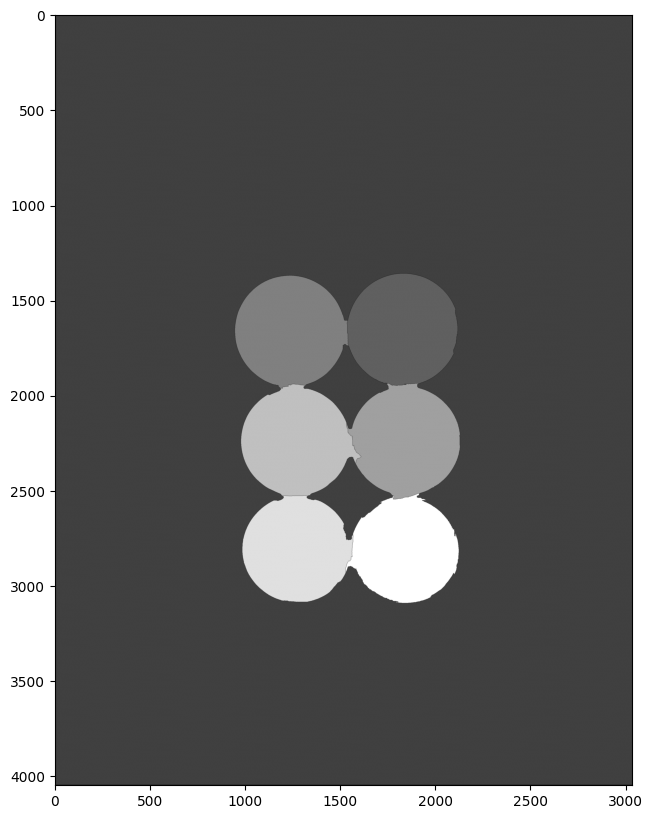

In [27]:
markers = cv2.watershed(img, markers)
display(markers)

In [28]:
contours, hierarchy = cv2.findContours(markers.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

for i in range(len(contours)):
    if hierarchy[0][i][3] == -1:
        cv2.drawContours(sep_coins, contours, i, (255, 0, 0), 10)

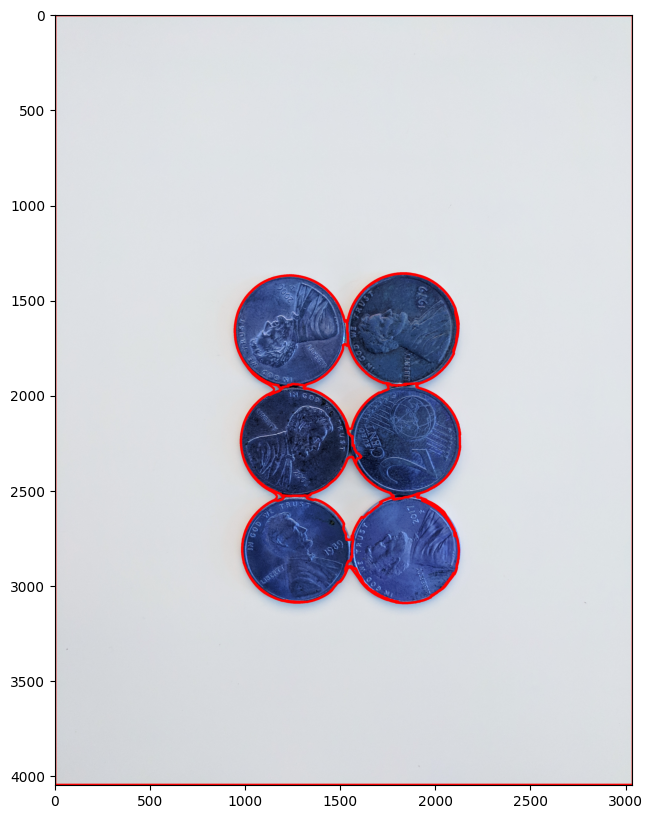

In [29]:
display(sep_coins)

# Custom Seeds with Watershed Algorithm

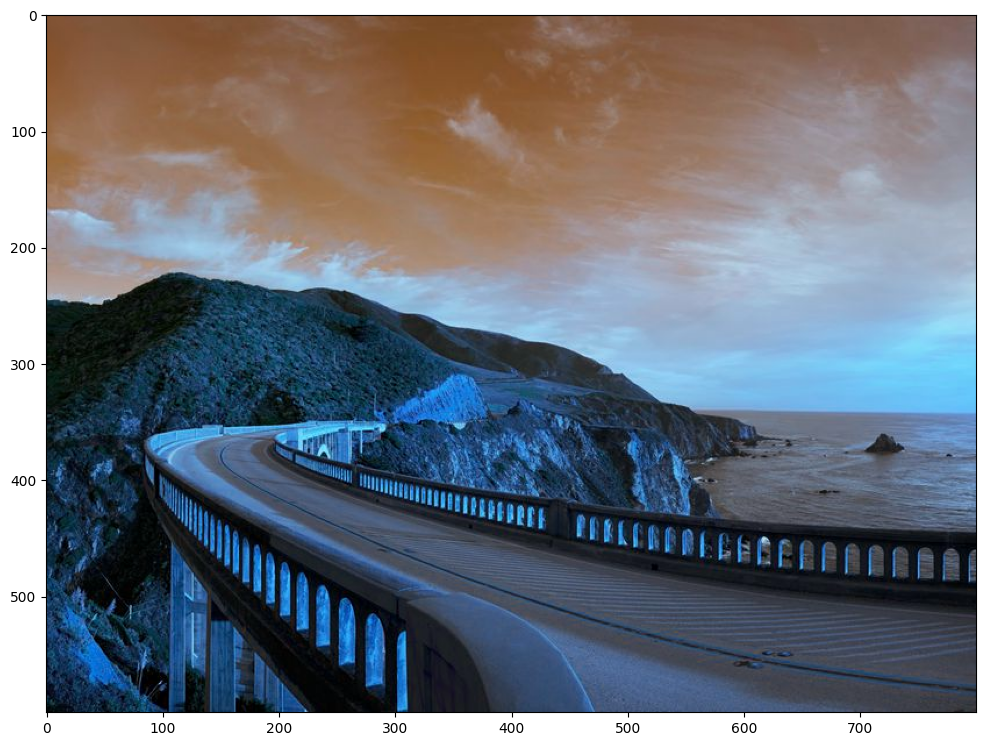

In [30]:
road = cv2.imread('../DATA/road_image.jpg')
display(road)

In [31]:
road_copy = np.copy(road)

In [32]:
marker_image = np.zeros(road.shape[:2], dtype=np.int32)
segments = np.zeros(road.shape, dtype=np.uint8)

In [33]:
from matplotlib import cm

In [34]:
cm.tab10(0)

(np.float64(0.12156862745098039),
 np.float64(0.4666666666666667),
 np.float64(0.7058823529411765),
 np.float64(1.0))

In [35]:
def create_rgb(i):
    return tuple(np.array(cm.tab10(i)[:3])*255)

In [36]:
colors = []
for i in range(10):
    colors.append(create_rgb(i))

In [37]:
colors

[(np.float64(31.0), np.float64(119.0), np.float64(180.0)),
 (np.float64(255.0), np.float64(127.0), np.float64(14.0)),
 (np.float64(44.0), np.float64(160.0), np.float64(44.0)),
 (np.float64(214.0), np.float64(39.0), np.float64(40.0)),
 (np.float64(148.0), np.float64(103.0), np.float64(189.0)),
 (np.float64(140.0), np.float64(86.0), np.float64(75.0)),
 (np.float64(227.0), np.float64(119.0), np.float64(194.0)),
 (np.float64(127.0), np.float64(127.0), np.float64(127.0)),
 (np.float64(188.0), np.float64(189.0), np.float64(34.0)),
 (np.float64(23.0), np.float64(190.0), np.float64(207.0))]

In [42]:
###
# Global Variables
# Count of colors
n_markers = 10

# Color choice
current_marker = 1

# Markers updation by watershed algo.
marks_updated = False

In [43]:
### Callback function

def mouse_callback(event, x, y, flags, param):
    global marks_updated

    if event == cv2.EVENT_LBUTTONDOWN:
        # Markers passed to the watershed algorithm
        cv2.circle(marker_image, (x,y), 10, (current_marker), 1)

        # User sees on the road image
        cv2.circle(road_copy, (x,y), 10, colors[current_marker], -1)

        marks_updated = True

In [44]:
cv2.namedWindow('Road Image')
cv2. setMouseCallback('Road Image', mouse_callback)

while True:
    cv2.imshow('Watershed Segments', segments)
    cv2.imshow('Road Image', road_copy)

    # Close All Windows
    k = cv2.waitKey(1)

    if k == 27:
        break

    # Clearing all the color by pressing C key.
    elif k == ord('c'):
        road_copy = road.copy()
        marker_image = np.zeros(road.shape[:2], dtype=np.int32)
        segments = np.zeros(road.shape, dtype=np.uint8)
    
    # Update Color choice
    if marks_updated:
        marker_image_copy = marker_image.copy()
        cv2.watershed(road, marker_image_copy)

        segments = np.zeros(road.shape, dtype=np.uint8)

        for color_ind in range(n_markers):
            # Coloring segements, numpy call
            segments[marker_image_copy == (color_ind)] = colors[color_ind]

cv2.destroyAllWindows()